<a href="https://colab.research.google.com/github/MateusAFalcao/RNA-e-Deep-Learning---CESAR-School-2025.02/blob/main/C%C3%B3pia_de_2_6_LinearRegressionSalaryData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regressão Linear com PyTorch - Dataset Salary Data

## Objetivos

Este exemplo utiliza regressão linear com um novo dataset vindo do Kaggle (https://www.kaggle.com/datasets/abhishek14398/salary-dataset-simple-linear-regression).

Utiliza-se:
- a função de perda MSE do PyTorch,
- treinamento dos parâmetros via gradiente descendente usando o otimizador.
- A rede é criada com uma camada nn.Linear()
- Divisão entre dataset de treinamento e validação

## Importação dos pacotes

In [1]:
%matplotlib inline
import torch
from torch import nn, optim
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(1234)

## Leitura dos dados

In [17]:
!curl -L -o /content/house-sales.zip \
https://www.kaggle.com/api/v1/datasets/download/harlfoxem/housesalesprediction

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  779k  100  779k    0     0  2352k      0 --:--:-- --:--:-- --:--:-- 2352k


In [18]:
!unzip -o /content/house-sales.zip -d /content/

Archive:  /content/house-sales.zip
  inflating: /content/kc_house_data.csv  


In [19]:
df = pd.read_csv('kc_house_data.csv')

print("Shape original:", df.shape)
print(df.head())

df = df.drop(columns=['id', 'date'])

X = df.drop(columns=['price']).values   # 18 features
y = df[['price']].values                # target: preço do imóvel (USD)

print(f"\nShape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print(f"\nFeatures utilizadas:\n{list(df.drop(columns=['price']).columns)}")

Shape original: (21613, 21)
           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900.0         3       1.00         1180   
1  6414100192  20141209T000000  538000.0         3       2.25         2570   
2  5631500400  20150225T000000  180000.0         2       1.00          770   
3  2487200875  20141209T000000  604000.0         4       3.00         1960   
4  1954400510  20150218T000000  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0     0  ...      8        1680              0   

   yr_built  yr_renova

### Normalização dos dados

In [20]:
x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X)

y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y)

In [21]:
# mesma proporção do notebook original
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y_scaled, test_size=0.3, random_state=42
)

# Converte para tensores float32
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val,   dtype=torch.float32)
y_val_tensor   = torch.tensor(y_val,   dtype=torch.float32)

print("\nX_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_val_tensor shape:  ", X_val_tensor.shape)
print("y_val_tensor shape:  ", y_val_tensor.shape)


X_train_tensor shape: torch.Size([15129, 18])
y_train_tensor shape: torch.Size([15129, 1])
X_val_tensor shape:   torch.Size([6484, 18])
y_val_tensor shape:   torch.Size([6484, 1])


## Criação do modelo da rede

In [24]:
# ADAPTAÇÃO: agora temos n_features entradas (não mais apenas 1)
n_features = X_train_tensor.shape[1]   # 18
model = nn.Linear(n_features, 1)

### Verificando a inicialização dos parâmetros

In [25]:
print("\nPesos iniciais (primeiros 5):", model.weight.data[0, :5])
print("Bias inicial:", model.bias.data)


Pesos iniciais (primeiros 5): tensor([-0.0922, -0.1156,  0.0610,  0.2199,  0.1131])
Bias inicial: tensor([-0.1994])


### Testando o predict da rede

In [27]:
print(model(X_train_tensor[:3]))

tensor([[-0.2356],
        [-0.4230],
        [-0.4293]], grad_fn=<AddmmBackward0>)


## Treinamento

### Definindo função de perda e otimizador

In [28]:
criterion = nn.MSELoss()

#learning rate de 0.01 para múltiplas features (0.3 pode causar divergência)
optimizer = optim.SGD(model.parameters(), lr=0.01)


### Laço de treinamento

In [29]:
def train_epoch(model, optimizer, criterion, X_train, y_train):
    model.train()                        # modo treino
    optimizer.zero_grad()                # zera os gradientes acumulados
    outputs = model(X_train)             # forward pass
    loss = criterion(outputs, y_train)   # calcula MSE
    loss.backward()                      # backward pass
    optimizer.step()                     # atualiza pesos
    return loss.item()

In [30]:
def validate_epoch(model, criterion, X_val, y_val):
    model.eval()                         # modo avaliação
    with torch.no_grad():                # desativa cálculo de gradientes
        outputs = model(X_val)
        loss = criterion(outputs, y_val)
    return loss.item()

In [34]:
num_epochs   = 120
train_losses = []
val_losses   = []

for epoch in range(num_epochs):

    train_loss = train_epoch(
        model, optimizer, criterion, X_train_tensor, y_train_tensor
    )
    train_losses.append(train_loss)

    val_loss = validate_epoch(model, criterion, X_val_tensor, y_val_tensor)
    val_losses.append(val_loss)

    if (epoch + 1) % 20 == 0:
        print(
            f'Epoch [{epoch+1}/{num_epochs}]  '
            f'Train Loss: {train_loss:.6f}  '
            f'Val Loss: {val_loss:.6f}'
        )

Epoch [20/120]  Train Loss: 0.305296  Val Loss: 0.338056
Epoch [40/120]  Train Loss: 0.302198  Val Loss: 0.334502
Epoch [60/120]  Train Loss: 0.299907  Val Loss: 0.331860
Epoch [80/120]  Train Loss: 0.298174  Val Loss: 0.329851
Epoch [100/120]  Train Loss: 0.296840  Val Loss: 0.328299
Epoch [120/120]  Train Loss: 0.295798  Val Loss: 0.327084


## Avaliação

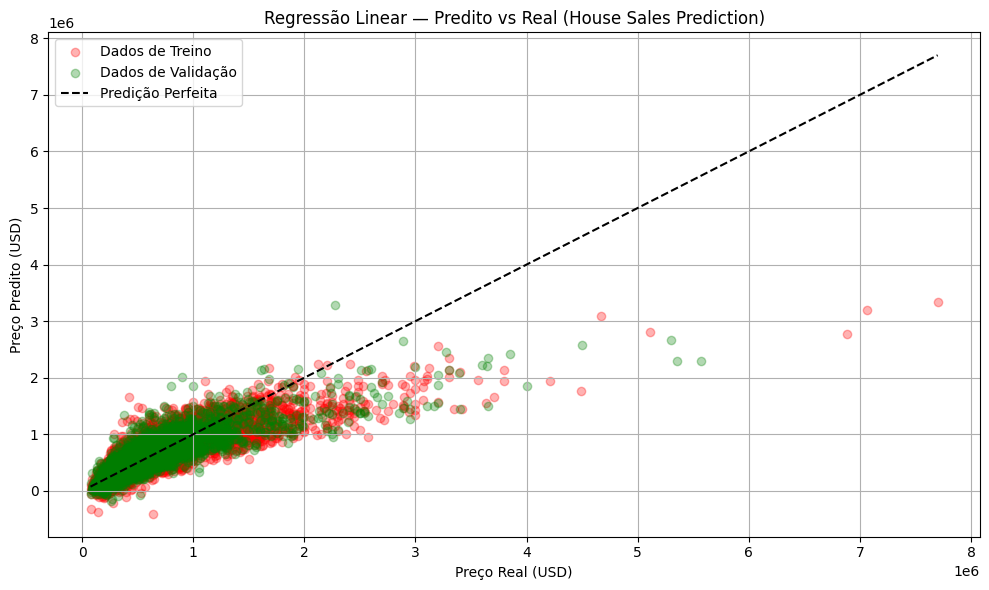

In [35]:
y_pred_train = model(X_train_tensor).detach().numpy()
y_pred_val   = model(X_val_tensor).detach().numpy()

# Desnormaliza para a escala original (USD) — facilita a interpretação
y_pred_train_real = y_scaler.inverse_transform(y_pred_train)
y_pred_val_real   = y_scaler.inverse_transform(y_pred_val)
y_train_real      = y_scaler.inverse_transform(y_train)
y_val_real        = y_scaler.inverse_transform(y_val)

# ADAPTAÇÃO: com múltiplas features, não é possível plotar uma reta 2D.
# Usamos Scatter "Preço Real vs Preço Predito": pontos na diagonal = boas previsões.
plt.figure(figsize=(10, 6))
plt.scatter(y_train_real, y_pred_train_real,
            alpha=0.3, color='red',   label='Dados de Treino')
plt.scatter(y_val_real,   y_pred_val_real,
            alpha=0.3, color='green', label='Dados de Validação')

# Linha de referência: predição perfeita (y_pred == y_real)
lim_min = min(y_train_real.min(), y_val_real.min())
lim_max = max(y_train_real.max(), y_val_real.max())
plt.plot([lim_min, lim_max], [lim_min, lim_max],
         'k--', linewidth=1.5, label='Predição Perfeita')

plt.xlabel('Preço Real (USD)')
plt.ylabel('Preço Predito (USD)')
plt.title('Regressão Linear — Predito vs Real (House Sales Prediction)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

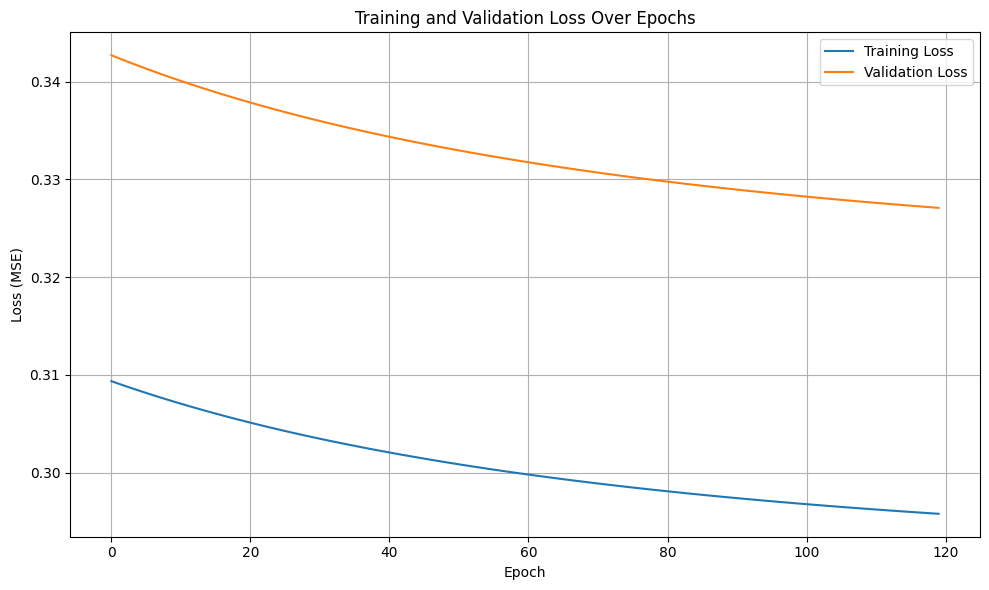

In [36]:
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses,   label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#Observações

Na parte da avaliação, usei o auxílio do Claude para plotar os gráficos.

Sobre o modelo: No gráfico do valor predito x valor real, ficou evidente que o modelo funciona muito bem para valores baixos. Porém o modelo não conseguiu prever os imóveis mais caros, o que é "esperado" porque foi aplicado um modelo linear para tentar prever dados que não tem uma relação linear.